# 02 - Treino DNN (NumPy)

Random search focado na vizinhança da configuração final, usando a lógica do `scripts/ensemble_3_models.py`.
Cada trial treina em `dataset_combined + dataset-exemplos`, faz early stopping em `subm1` e avalia em `subm2`.


In [2]:
import sys
import os
import pickle
import random
import time

sys.path.append(os.path.abspath('..'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, auc, classification_report, confusion_matrix, f1_score, roc_curve
from sklearn.preprocessing import label_binarize

from src.data_processing import clean_text
from src.hyperopt import build_random_search
from src.models_numpy.dnn import (
    AdamOptimizer,
    BatchNormalizationLayer,
    CategoricalCrossEntropy,
    Dataset,
    DenseLayer,
    DropoutLayer,
    NeuralNetwork,
    ReLUActivation,
    SoftmaxActivation,
    accuracy,
)
from src.vectorizer import create_vectorizer


In [3]:
SEED = 42
N_ITERATIONS = 12

random.seed(SEED)
np.random.seed(SEED)


## 1. Dados


In [4]:
ROOT = os.path.abspath('..')
CLASSES = ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']
LABEL_MAP = {label: i for i, label in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)

TRAIN_PATH = os.path.join(ROOT, 'data', 'processed', 'dataset_combined.csv')
EXEMPLOS_PATH = os.path.join(ROOT, 'data', 'validation', 'dataset-exemplos.csv')
EARLY_STOP_PATH = os.path.join(ROOT, 'data', 'validation', 'subm1_labels_revealed.csv')
EVAL_PATH = os.path.join(ROOT, 'data', 'validation', 'subm2_labels_revealed.csv')
SAVED_MODELS_DIR = os.path.join(ROOT, 'saved_models')


def load_data(path):
    df = pd.read_csv(path, sep=';')
    df = df[df['Label'].isin(CLASSES)].copy()
    df['label_id'] = df['Label'].map(LABEL_MAP)
    return df


def one_hot(labels):
    oh = np.zeros((len(labels), NUM_CLASSES))
    for i, label in enumerate(labels):
        oh[i, label] = 1
    return oh


df_train = load_data(TRAIN_PATH)
df_exemplos = load_data(EXEMPLOS_PATH)
df_full = pd.concat([df_train, df_exemplos], ignore_index=True)
df_es = load_data(EARLY_STOP_PATH)
df_eval = load_data(EVAL_PATH)

print(f'Train final: {len(df_full)} (combined={len(df_train)} + exemplos={len(df_exemplos)})')
print(f'Early stop (subm1): {len(df_es)}')
print(f'Eval (subm2): {len(df_eval)}')


Train final: 4740 (combined=4615 + exemplos=125)
Early stop (subm1): 100
Eval (subm2): 100


## 2. Espaço de Busca


In [5]:
param_grid = {
    'vectorizer_type': ['forensic'],
    'max_words': [1500, 2000, 2500],
    'hidden_layers': [[128, 64], [256, 128], [256, 128, 64]],
    'dropout': [0.3, 0.4, 0.5],
    'lr': [0.0005, 0.001, 0.002],
    'batch_size': [64],
    'use_batchnorm': [True, False],
    'epochs': [100],
    'patience': [15],
}

for k, v in param_grid.items():
    print(f'{k}: {v}')


vectorizer_type: ['forensic']
max_words: [1500, 2000, 2500]
hidden_layers: [[128, 64], [256, 128], [256, 128, 64]]
dropout: [0.3, 0.4, 0.5]
lr: [0.0005, 0.001, 0.002]
batch_size: [64]
use_batchnorm: [True, False]
epochs: [100]
patience: [15]


## 3. Funções


In [6]:
def build_dnn(params, input_dim):
    model = NeuralNetwork(
        epochs=params['epochs'],
        batch_size=params['batch_size'],
        optimizer=AdamOptimizer(learning_rate=params['lr']),
        verbose=False,
        loss=CategoricalCrossEntropy,
        metric=accuracy,
        early_stopping=True,
        patience=params['patience'],
    )

    prev_dim = input_dim
    for hidden_dim in params['hidden_layers']:
        model.add(DenseLayer(hidden_dim, prev_dim))
        if params['use_batchnorm']:
            model.add(BatchNormalizationLayer())
        model.add(ReLUActivation())
        model.add(DropoutLayer(params['dropout']))
        prev_dim = hidden_dim

    model.add(DenseLayer(NUM_CLASSES, prev_dim))
    model.add(SoftmaxActivation())
    return model


def train_dnn_trial(params, texts_tr, y_tr, texts_es, y_es):
    texts_tr_clean = [clean_text(text) for text in texts_tr]
    texts_es_clean = [clean_text(text) for text in texts_es]

    vectorizer = create_vectorizer(params['vectorizer_type'], max_words=params['max_words'])
    X_tr = vectorizer.fit_transform(texts_tr_clean, texts_tr)
    X_es = vectorizer.transform(texts_es_clean, texts_es)

    model = build_dnn(params, X_tr.shape[1])
    start = time.time()
    history = model.fit(
        Dataset(X_tr, one_hot(y_tr)),
        Dataset(X_es, one_hot(y_es)),
    )
    train_time = time.time() - start
    return model, vectorizer, history, train_time


def predict_dnn(model, vectorizer, texts_raw):
    texts_clean = [clean_text(text) for text in texts_raw]
    X = vectorizer.transform(texts_clean, texts_raw)
    return model.predict(Dataset(X, np.zeros((len(texts_raw), NUM_CLASSES))))


def evaluate_probs(probs, labels, name):
    preds = np.argmax(probs, axis=1)
    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average='macro', zero_division=0)

    print(f'\n=== {name} ===')
    print(f'Accuracy: {acc:.4f} | Macro F1: {macro_f1:.4f}')
    print(classification_report(labels, preds, target_names=CLASSES, zero_division=0))

    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(labels, preds)
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(NUM_CLASSES),
        yticks=np.arange(NUM_CLASSES),
        xticklabels=CLASSES,
        yticklabels=CLASSES,
        ylabel='Real',
        xlabel='Previsto',
        title=f'Matriz de Confusão — {name}',
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')

    plt.tight_layout()
    plt.show()
    return acc, macro_f1, preds


## 4. Random Search com Protocolo Final


In [7]:
results = []
best_selection_score = -1.0
best_payload = None

texts_tr = df_full['Text'].tolist()
y_tr = df_full['label_id'].values
texts_es = df_es['Text'].tolist()
y_es = df_es['label_id'].values
texts_eval = df_eval['Text'].tolist()
y_eval = df_eval['label_id'].values

for i, params in enumerate(build_random_search(param_grid, n_iter=N_ITERATIONS, random_state=SEED), start=1):
    print(f"[{i}/{N_ITERATIONS}] hidden={params['hidden_layers']} drop={params['dropout']} lr={params['lr']} mw={params['max_words']}")

    model, vectorizer, history, train_time = train_dnn_trial(params, texts_tr, y_tr, texts_es, y_es)
    probs_es = predict_dnn(model, vectorizer, texts_es)
    probs_eval = predict_dnn(model, vectorizer, texts_eval)

    es_acc = accuracy_score(y_es, np.argmax(probs_es, axis=1))
    eval_acc = accuracy_score(y_eval, np.argmax(probs_eval, axis=1))
    es_f1 = f1_score(y_es, np.argmax(probs_es, axis=1), average='macro', zero_division=0)
    eval_f1 = f1_score(y_eval, np.argmax(probs_eval, axis=1), average='macro', zero_division=0)
    selection_score = (es_acc + eval_acc) / 2

    print(f'  -> ES acc={es_acc:.4f} f1={es_f1:.4f} | Eval acc={eval_acc:.4f} f1={eval_f1:.4f} | score={selection_score:.4f}')

    results.append({
        'iteration': i,
        'vectorizer_type': params['vectorizer_type'],
        'max_words': params['max_words'],
        'hidden_layers': str(params['hidden_layers']),
        'dropout': params['dropout'],
        'lr': params['lr'],
        'batch_size': params['batch_size'],
        'use_batchnorm': params['use_batchnorm'],
        'es_acc': es_acc,
        'es_f1': es_f1,
        'eval_acc': eval_acc,
        'eval_f1': eval_f1,
        'selection_score': selection_score,
        'train_time': train_time,
    })

    if selection_score > best_selection_score:
        best_selection_score = selection_score
        best_payload = {
            'params': params.copy(),
            'model': model,
            'vectorizer': vectorizer,
            'probs_es': probs_es,
            'probs_eval': probs_eval,
        }
        print('  *** NOVO MELHOR MODELO ***')

results_df = pd.DataFrame(results).sort_values(['selection_score', 'eval_acc', 'es_acc'], ascending=False).reset_index(drop=True)
results_df.head()


[1/12] hidden=[256, 128, 64] drop=0.4 lr=0.0005 mw=1500
  -> ES acc=0.5800 f1=0.5351 | Eval acc=0.6900 f1=0.6654 | score=0.6350
  *** NOVO MELHOR MODELO ***
[2/12] hidden=[128, 64] drop=0.3 lr=0.0005 mw=1500
  -> ES acc=0.6000 f1=0.5628 | Eval acc=0.7400 f1=0.7179 | score=0.6700
  *** NOVO MELHOR MODELO ***
[3/12] hidden=[256, 128, 64] drop=0.4 lr=0.0005 mw=2000
  -> ES acc=0.5700 f1=0.5030 | Eval acc=0.6400 f1=0.5916 | score=0.6050
[4/12] hidden=[256, 128] drop=0.3 lr=0.0005 mw=1500
  -> ES acc=0.6500 f1=0.6262 | Eval acc=0.6900 f1=0.6655 | score=0.6700
[5/12] hidden=[256, 128, 64] drop=0.4 lr=0.002 mw=1500
  -> ES acc=0.5800 f1=0.5420 | Eval acc=0.7500 f1=0.7305 | score=0.6650
[6/12] hidden=[128, 64] drop=0.5 lr=0.0005 mw=2500
  -> ES acc=0.6500 f1=0.6239 | Eval acc=0.7100 f1=0.6841 | score=0.6800
  *** NOVO MELHOR MODELO ***
[7/12] hidden=[256, 128] drop=0.4 lr=0.001 mw=1500
  -> ES acc=0.6200 f1=0.5944 | Eval acc=0.6900 f1=0.6638 | score=0.6550
[8/12] hidden=[256, 128] drop=0.5 lr=

,iteration,vectorizer_type,max_words,hidden_layers,dropout,lr,batch_size,use_batchnorm,es_acc,es_f1,eval_acc,eval_f1,selection_score,train_time
0,8,forensic,2500,"[256, 128]",0.5,0.0020,64,True,0.68,0.645815,0.72,0.710751,0.700,17.292563
1,6,forensic,2500,"[128, 64]",0.5,0.0005,64,True,0.65,0.623917,0.71,0.684127,0.680,8.549843
2,2,forensic,1500,"[128, 64]",0.3,0.0005,64,True,0.60,0.562845,0.74,0.717856,0.670,2.787816
3,4,forensic,1500,"[256, 128]",0.3,0.0005,64,True,0.65,0.626246,0.69,0.665470,0.670,9.564902
4,5,forensic,1500,"[256, 128, 64]",0.4,0.0020,64,False,0.58,0.541983,0.75,0.730478,0.665,6.220908


## 5. Resultados


 iteration vectorizer_type  max_words  hidden_layers  dropout     lr  batch_size  use_batchnorm  es_acc    es_f1  eval_acc  eval_f1  selection_score  train_time
         8        forensic       2500     [256, 128]      0.5 0.0020          64           True    0.68 0.645815      0.72 0.710751            0.700   17.292563
         6        forensic       2500      [128, 64]      0.5 0.0005          64           True    0.65 0.623917      0.71 0.684127            0.680    8.549843
         2        forensic       1500      [128, 64]      0.3 0.0005          64           True    0.60 0.562845      0.74 0.717856            0.670    2.787816
         4        forensic       1500     [256, 128]      0.3 0.0005          64           True    0.65 0.626246      0.69 0.665470            0.670    9.564902
         5        forensic       1500 [256, 128, 64]      0.4 0.0020          64          False    0.58 0.541983      0.75 0.730478            0.665    6.220908
         7        forensic       1

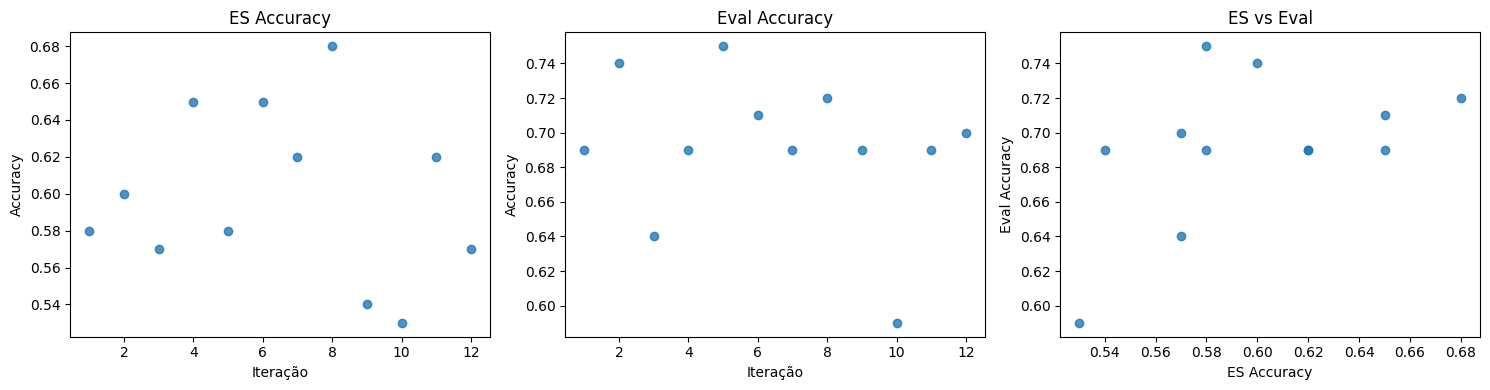

In [8]:
print(results_df.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(results_df['iteration'], results_df['es_acc'], alpha=0.8)
axes[0].set_title('ES Accuracy')
axes[0].set_xlabel('Iteração')
axes[0].set_ylabel('Accuracy')

axes[1].scatter(results_df['iteration'], results_df['eval_acc'], alpha=0.8)
axes[1].set_title('Eval Accuracy')
axes[1].set_xlabel('Iteração')
axes[1].set_ylabel('Accuracy')

axes[2].scatter(results_df['es_acc'], results_df['eval_acc'], alpha=0.8)
axes[2].set_title('ES vs Eval')
axes[2].set_xlabel('ES Accuracy')
axes[2].set_ylabel('Eval Accuracy')

plt.tight_layout()
plt.show()


## 6. Avaliação do Melhor Modelo


{'vectorizer_type': 'forensic', 'max_words': 2500, 'hidden_layers': [256, 128], 'dropout': 0.5, 'lr': 0.002, 'batch_size': 64, 'use_batchnorm': True, 'epochs': 100, 'patience': 15}
Selection score: 0.7000

=== Melhor DNN - ES (subm1) ===
Accuracy: 0.6800 | Macro F1: 0.6458
              precision    recall  f1-score   support

   Anthropic       0.83      0.59      0.69        17
      Google       0.55      0.65      0.59        17
       Human       0.84      0.76      0.80        34
        Meta       0.73      0.89      0.80        18
      OpenAI       0.33      0.36      0.34        14

    accuracy                           0.68       100
   macro avg       0.66      0.65      0.65       100
weighted avg       0.70      0.68      0.68       100



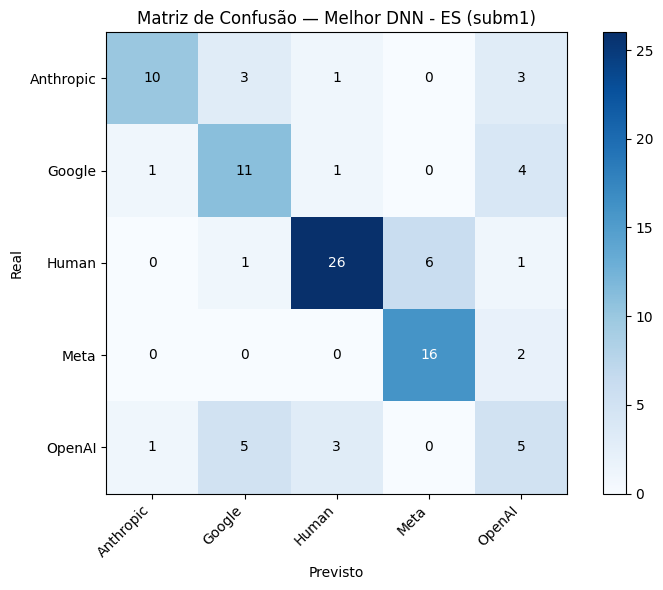


=== Melhor DNN - Eval (subm2) ===
Accuracy: 0.7200 | Macro F1: 0.7108
              precision    recall  f1-score   support

   Anthropic       0.60      0.75      0.67        16
      Google       0.76      0.72      0.74        18
       Human       0.81      0.74      0.77        34
        Meta       0.81      0.81      0.81        16
      OpenAI       0.56      0.56      0.56        16

    accuracy                           0.72       100
   macro avg       0.71      0.72      0.71       100
weighted avg       0.73      0.72      0.72       100



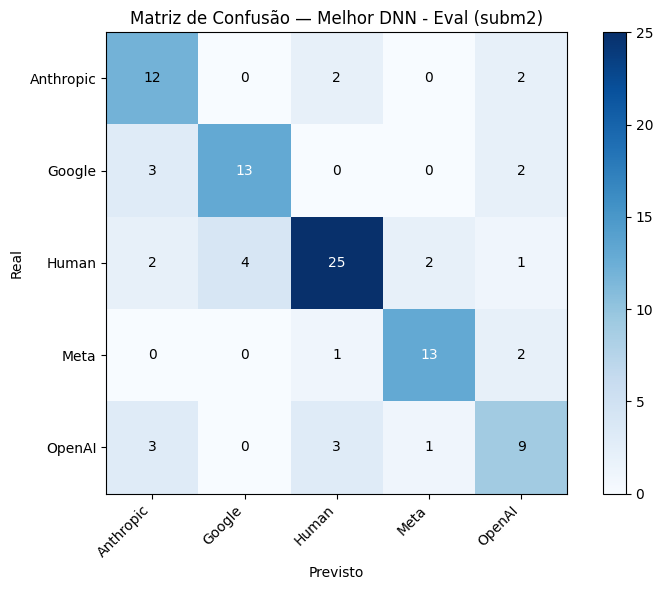

In [9]:
best_model = best_payload['model']
best_vectorizer = best_payload['vectorizer']
best_params = best_payload['params']

print(best_params)
print(f'Selection score: {best_selection_score:.4f}')

es_acc, es_f1, _ = evaluate_probs(best_payload['probs_es'], y_es, 'Melhor DNN - ES (subm1)')
eval_acc, eval_f1, _ = evaluate_probs(best_payload['probs_eval'], y_eval, 'Melhor DNN - Eval (subm2)')


## 7. Guardar Pesos


In [11]:
os.makedirs(SAVED_MODELS_DIR, exist_ok=True)
model_path = os.path.join(SAVED_MODELS_DIR, 'dnn_final_model.npz')
vectorizer_path = os.path.join(SAVED_MODELS_DIR, 'dnn_final_vectorizer.pkl')

best_model.save(model_path)
with open(vectorizer_path, 'wb') as f:
    pickle.dump(best_vectorizer, f)

print(f'Modelo guardado em {model_path}')
print(f'Vectorizer guardado em {vectorizer_path}')


Modelo guardado em /home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/saved_models/dnn_final_model.npz
Vectorizer guardado em /home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/saved_models/dnn_final_vectorizer.pkl


## 8. AUC-ROC

In [12]:
from sklearn.preprocessing import label_binarize

def compute_macro_auc(probs, labels):
    labels_bin = label_binarize(labels, classes=range(NUM_CLASSES))
    aucs = []
    for i in range(NUM_CLASSES):
        fpr_i, tpr_i, _ = roc_curve(labels_bin[:, i], probs[:, i])
        aucs.append(auc(fpr_i, tpr_i))
    return np.mean(aucs)

dnn_auc_val1 = compute_macro_auc(best_payload['probs_es'], y_es)
dnn_auc_val2 = compute_macro_auc(best_payload['probs_eval'], y_eval)

print(f'DNN — Val1 Macro AUC: {dnn_auc_val1:.4f}')
print(f'DNN — Val2 Macro AUC: {dnn_auc_val2:.4f}')

DNN — Val1 Macro AUC: 0.8837
DNN — Val2 Macro AUC: 0.9052


## 9. Comparação DNN vs. Regressão Logística

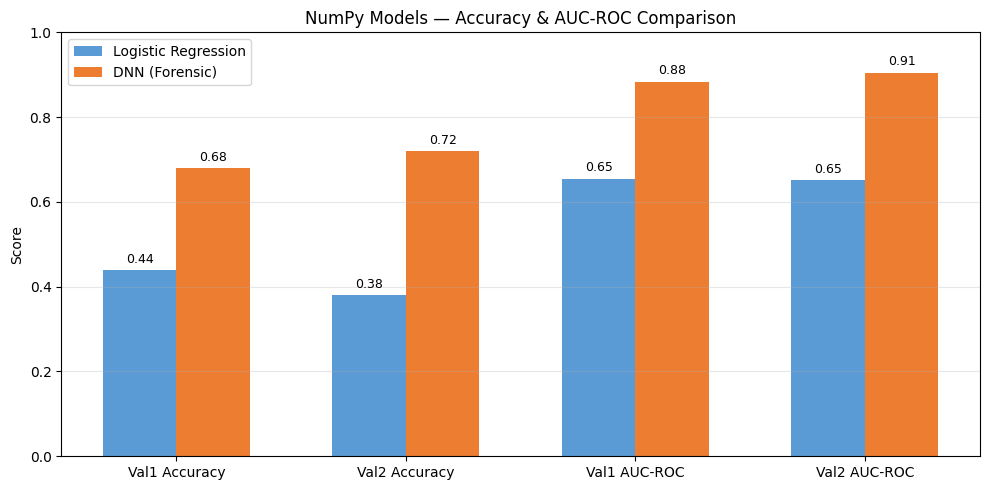

In [13]:
logreg_val1_acc = 0.44
logreg_val2_acc = 0.38
logreg_val1_auc = 0.6548
logreg_val2_auc = 0.6510

dnn_val1_acc = es_acc
dnn_val2_acc = eval_acc

models = ['Logistic Regression', 'DNN (Forensic)']
metrics = ['Val1 Accuracy', 'Val2 Accuracy', 'Val1 AUC-ROC', 'Val2 AUC-ROC']
logreg_vals = [logreg_val1_acc, logreg_val2_acc, logreg_val1_auc, logreg_val2_auc]
dnn_vals = [dnn_val1_acc, dnn_val2_acc, dnn_auc_val1, dnn_auc_val2]

x = np.arange(len(metrics))
width = 0.32

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, logreg_vals, width, label='Logistic Regression', color='#5B9BD5')
bars2 = ax.bar(x + width/2, dnn_vals, width, label='DNN (Forensic)', color='#ED7D31')

ax.set_ylabel('Score')
ax.set_title('NumPy Models — Accuracy & AUC-ROC Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()